In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel("Intern_Performance_Dashboard.xlsx")

# Preview data
df

,Intern ID,Intern Name,Domain,Week 1 Tasks,Week 2 Tasks,Week 3 Tasks,Week 4 Tasks,Total Tasks Completed,Total working days,Days present,Days absent,Attendence
0,101,Aarav,Web Development,yes,no,no,no,1,22,20,2,90.909091
1,102,Diya,UI/UX Design,no,yes,no,yes,2,22,19,3,86.363636
2,103,Rohan,Data Analytics,yes,no,yes,yes,3,22,21,1,95.454545
3,104,Sneha,Digital Marketing,yes,yes,no,no,2,22,19,3,86.363636
4,105,Kiran,HR & Operations,yes,yes,yes,no,3,22,0,22,0.000000
5,106,sreeja,UI/UX Design,no,yes,yes,no,2,22,21,1,95.454545
6,107,madhu,Web Development,yes,yes,no,yes,3,22,20,2,90.909091
7,108,vijay,UI/UX Design,yes,no,yes,yes,3,22,19,3,86.363636
8,109,anit,HR & Operations,no,yes,no,yes,2,22,21,1,95.454545
9,110,sanjeevani,Data Analytics,no,no,no,no,0,22,5,17,22.727273


In [3]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Intern ID              50 non-null     int64  
 1   Intern Name            50 non-null     object 
 2   Domain                 50 non-null     object 
 3   Week 1 Tasks           50 non-null     object 
 4   Week 2 Tasks           50 non-null     object 
 5   Week 3 Tasks           50 non-null     object 
 6   Week 4 Tasks           50 non-null     object 
 7   Total Tasks Completed  50 non-null     int64  
 8   Total working days     50 non-null     int64  
 9   Days present           50 non-null     int64  
 10  Days absent            50 non-null     int64  
 11  Attendence             50 non-null     float64
dtypes: float64(1), int64(5), object(6)
memory usage: 4.8+ KB


,Intern ID,Intern Name,Domain,Week 1 Tasks,Week 2 Tasks,Week 3 Tasks,Week 4 Tasks,Total Tasks Completed,Total working days,Days present,Days absent,Attendence
count,50.00000,50,50,50,50,50,50,50.000000,50.0,50.000000,50.000000,50.000000
unique,NaN,50,5,2,2,2,2,NaN,NaN,NaN,NaN,NaN
top,NaN,Aarav,Web Development,yes,yes,no,yes,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,13,38,37,25,36,NaN,NaN,NaN,NaN,NaN
mean,125.50000,NaN,NaN,NaN,NaN,NaN,NaN,2.720000,22.0,17.660000,4.340000,80.272727
std,14.57738,NaN,NaN,NaN,NaN,NaN,NaN,1.050559,0.0,6.083132,6.083132,27.650598
min,101.00000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,22.0,0.000000,0.000000,0.000000
25%,113.25000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,22.0,17.000000,1.000000,77.272727
50%,125.50000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,22.0,20.000000,2.000000,90.909091
75%,137.75000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,22.0,21.000000,5.000000,95.454545


In [4]:
# Check duplicates
df.duplicated().sum()

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Duplicates removed. New shape:", df.shape)

Duplicates removed. New shape: (50, 12)


In [5]:
df.isnull().sum()

Intern ID                0
Intern Name              0
Domain                   0
Week 1 Tasks             0
Week 2 Tasks             0
Week 3 Tasks             0
Week 4 Tasks             0
Total Tasks Completed    0
Total working days       0
Days present             0
Days absent              0
Attendence               0
dtype: int64

In [6]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled.")

Missing values handled.


C:\Users\smp_0\AppData\Local\Temp\ipykernel_13324\700671674.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\smp_0\AppData\Local\Temp\ipykernel_13324\700671674.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [7]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] >= lower) & (data[column] <= upper)]

In [8]:
for col in num_cols:
    df = remove_outliers_iqr(df, col)

print("Outliers handled using IQR method.")

Outliers handled using IQR method.


In [9]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [10]:
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

In [11]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 0 to 49
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   intern_id              41 non-null     int64  
 1   intern_name            41 non-null     object 
 2   domain                 41 non-null     object 
 3   week_1_tasks           41 non-null     object 
 4   week_2_tasks           41 non-null     object 
 5   week_3_tasks           41 non-null     object 
 6   week_4_tasks           41 non-null     object 
 7   total_tasks_completed  41 non-null     int64  
 8   total_working_days     41 non-null     int64  
 9   days_present           41 non-null     int64  
 10  days_absent            41 non-null     int64  
 11  attendence             41 non-null     float64
dtypes: float64(1), int64(5), object(6)
memory usage: 4.2+ KB


intern_id                0
intern_name              0
domain                   0
week_1_tasks             0
week_2_tasks             0
week_3_tasks             0
week_4_tasks             0
total_tasks_completed    0
total_working_days       0
days_present             0
days_absent              0
attendence               0
dtype: int64

In [12]:
df.to_excel("Intern_Performance_Dashboard_Cleaned.xlsx", index=False)

In [13]:
df = pd.read_excel("Intern_Performance_Dashboard_Cleaned.xlsx")
df

,intern_id,intern_name,domain,week_1_tasks,week_2_tasks,week_3_tasks,week_4_tasks,total_tasks_completed,total_working_days,days_present,days_absent,attendence
0,101,Aarav,Web Development,yes,no,no,no,1,22,20,2,90.909091
1,102,Diya,UI/UX Design,no,yes,no,yes,2,22,19,3,86.363636
2,103,Rohan,Data Analytics,yes,no,yes,yes,3,22,21,1,95.454545
3,104,Sneha,Digital Marketing,yes,yes,no,no,2,22,19,3,86.363636
4,106,sreeja,UI/UX Design,no,yes,yes,no,2,22,21,1,95.454545
5,107,madhu,Web Development,yes,yes,no,yes,3,22,20,2,90.909091
6,108,vijay,UI/UX Design,yes,no,yes,yes,3,22,19,3,86.363636
7,109,anit,HR & Operations,no,yes,no,yes,2,22,21,1,95.454545
8,111,aditya,Web Development,no,yes,no,yes,2,22,22,0,100.000000
9,112,vibhanshu,Web Development,yes,yes,yes,yes,4,22,22,0,100.000000


In [14]:
round(df.attendence, 2)

0      90.91
1      86.36
2      95.45
3      86.36
4      95.45
5      90.91
6      86.36
7      95.45
8     100.00
9     100.00
10    100.00
11     72.73
12     95.45
13    100.00
14    100.00
15     81.82
16    100.00
17     90.91
18     95.45
19     95.45
20     95.45
21    100.00
22    100.00
23     68.18
24     86.36
25     77.27
26     81.82
27    100.00
28     86.36
29     72.73
30     86.36
31     95.45
32     81.82
33     86.36
34     95.45
35     95.45
36    100.00
37    100.00
38    100.00
39     77.27
40     95.45
Name: attendence, dtype: float64

In [15]:
df.attendence = round(df.attendence, 2)

In [16]:
df

,intern_id,intern_name,domain,week_1_tasks,week_2_tasks,week_3_tasks,week_4_tasks,total_tasks_completed,total_working_days,days_present,days_absent,attendence
0,101,Aarav,Web Development,yes,no,no,no,1,22,20,2,90.91
1,102,Diya,UI/UX Design,no,yes,no,yes,2,22,19,3,86.36
2,103,Rohan,Data Analytics,yes,no,yes,yes,3,22,21,1,95.45
3,104,Sneha,Digital Marketing,yes,yes,no,no,2,22,19,3,86.36
4,106,sreeja,UI/UX Design,no,yes,yes,no,2,22,21,1,95.45
5,107,madhu,Web Development,yes,yes,no,yes,3,22,20,2,90.91
6,108,vijay,UI/UX Design,yes,no,yes,yes,3,22,19,3,86.36
7,109,anit,HR & Operations,no,yes,no,yes,2,22,21,1,95.45
8,111,aditya,Web Development,no,yes,no,yes,2,22,22,0,100.00
9,112,vibhanshu,Web Development,yes,yes,yes,yes,4,22,22,0,100.00


In [17]:
df['intern_name'] = df['intern_name'].str.strip().str.title()

In [18]:
df

,intern_id,intern_name,domain,week_1_tasks,week_2_tasks,week_3_tasks,week_4_tasks,total_tasks_completed,total_working_days,days_present,days_absent,attendence
0,101,Aarav,Web Development,yes,no,no,no,1,22,20,2,90.91
1,102,Diya,UI/UX Design,no,yes,no,yes,2,22,19,3,86.36
2,103,Rohan,Data Analytics,yes,no,yes,yes,3,22,21,1,95.45
3,104,Sneha,Digital Marketing,yes,yes,no,no,2,22,19,3,86.36
4,106,Sreeja,UI/UX Design,no,yes,yes,no,2,22,21,1,95.45
5,107,Madhu,Web Development,yes,yes,no,yes,3,22,20,2,90.91
6,108,Vijay,UI/UX Design,yes,no,yes,yes,3,22,19,3,86.36
7,109,Anit,HR & Operations,no,yes,no,yes,2,22,21,1,95.45
8,111,Aditya,Web Development,no,yes,no,yes,2,22,22,0,100.00
9,112,Vibhanshu,Web Development,yes,yes,yes,yes,4,22,22,0,100.00


In [19]:
df['week_1_tasks'] = df['week_1_tasks'].str.strip().str.title()
df['week_2_tasks'] = df['week_2_tasks'].str.strip().str.title()
df['week_3_tasks'] = df['week_3_tasks'].str.strip().str.title()
df['week_4_tasks'] = df['week_4_tasks'].str.strip().str.title()

In [ ]:
df

In [20]:
# Clean and format column names
df.columns = (
    df.columns
      .str.replace('_', ' ')   
      .str.title()             
)

In [ ]:
df

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Intern_Performance_Dashboard.xlsx")
df

In [ ]:
# Shape of dataset
df.shape


In [ ]:
# Dataset info
df.info()

In [ ]:
df['Total Tasks Completed'].describe()

In [ ]:
plt.figure()
sns.histplot(df['Total Tasks Completed'], bins=10)
plt.title("Distribution of Total Tasks Completed")
plt.xlabel("Total Tasks Completed")
plt.ylabel("Count")
plt.show()

In [ ]:
df['Attendence'].describe()

In [ ]:
plt.figure()
sns.histplot(df['Attendence'], bins=10)
plt.title("Attendance Percentage Distribution")
plt.xlabel("Attendance %")
plt.ylabel("Count")
plt.show()

In [ ]:
plt.figure()
sns.boxplot(y=df['Total Tasks Completed'])
plt.title("Outliers in Total Tasks Completed")
plt.show()

In [ ]:
plt.figure()
sns.boxplot(y=df['Attendence'])
plt.title("Outliers in Attendance Percentage")
plt.show()

In [ ]:
plt.figure()
sns.scatterplot(x='Attendence', y='Total Tasks Completed', data=df)
plt.title("Attendance vs Total Tasks Completed")
plt.xlabel("Attendence %")
plt.ylabel("Total Tasks Completed")
plt.show()

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Domain', y='Total Tasks Completed', data=df)
plt.xticks(rotation=45)
plt.title("Domain-wise Task Completion")
plt.show()

In [ ]:
df['Performance Level'] = pd.qcut(
    df['Total Tasks Completed'], 
    q=2, 
    labels=['Low Performance', 'High Performance']
)

df['Attendance Level'] = pd.qcut(
    df['Attendence'], 
    q=2, 
    labels=['Low Attendance', 'High Attendance']
)

df[['Intern Name', 'Attendance Level', 'Performance Level']].head()

In [ ]:
pd.crosstab(df['Attendance Level'], df['Performance Level'])

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
df = pd.read_excel("Intern_Performance_Dashboard.xlsx")

df.head()

,Intern ID,Intern Name,Domain,Week 1 Tasks,Week 2 Tasks,Week 3 Tasks,Week 4 Tasks,Total Tasks Completed,Total working days,Days present,Days absent,Attendence
0,101,Aarav,Web Development,yes,no,no,no,1,22,20,2,90.909091
1,102,Diya,UI/UX Design,no,yes,no,yes,2,22,19,3,86.363636
2,103,Rohan,Data Analytics,yes,no,yes,yes,3,22,21,1,95.454545
3,104,Sneha,Digital Marketing,yes,yes,no,no,2,22,19,3,86.363636
4,105,Kiran,HR & Operations,yes,yes,yes,no,3,22,0,22,0.000000


In [23]:
df.columns

Index(['Intern ID', 'Intern Name', 'Domain', 'Week 1 Tasks', 'Week 2 Tasks',
       'Week 3 Tasks', 'Week 4 Tasks', 'Total Tasks Completed',
       'Total working days', 'Days present', 'Days absent', 'Attendence'],
      dtype='object')

In [24]:
df.shape

(50, 12)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Intern ID              50 non-null     int64  
 1   Intern Name            50 non-null     object 
 2   Domain                 50 non-null     object 
 3   Week 1 Tasks           50 non-null     object 
 4   Week 2 Tasks           50 non-null     object 
 5   Week 3 Tasks           50 non-null     object 
 6   Week 4 Tasks           50 non-null     object 
 7   Total Tasks Completed  50 non-null     int64  
 8   Total working days     50 non-null     int64  
 9   Days present           50 non-null     int64  
 10  Days absent            50 non-null     int64  
 11  Attendence             50 non-null     float64
dtypes: float64(1), int64(5), object(6)
memory usage: 4.8+ KB


In [26]:
df.dtypes

Intern ID                  int64
Intern Name               object
Domain                    object
Week 1 Tasks              object
Week 2 Tasks              object
Week 3 Tasks              object
Week 4 Tasks              object
Total Tasks Completed      int64
Total working days         int64
Days present               int64
Days absent                int64
Attendence               float64
dtype: object

In [8]:
# Convert yes/no to 1/0 for all weekly columns
week_columns = ["Week 1 Tasks", "Week 2 Tasks", 
                "Week 3 Tasks", "Week 4 Tasks"]
for col in week_columns:
    df[col] = df[col].str.lower().map({"yes": 1, "no": 0})
df.head()

,Intern ID,Intern Name,Domain,Week 1 Tasks,Week 2 Tasks,Week 3 Tasks,Week 4 Tasks,Total Tasks Completed,Total working days,Days present,Days absent,Attendence
0,101,Aarav,Web Development,1,0,0,0,1,22,20,2,90.909091
1,102,Diya,UI/UX Design,0,1,0,1,2,22,19,3,86.363636
2,103,Rohan,Data Analytics,1,0,1,1,3,22,21,1,95.454545
3,104,Sneha,Digital Marketing,1,1,0,0,2,22,19,3,86.363636
4,105,Kiran,HR & Operations,1,1,1,0,3,22,0,22,0.000000


In [9]:
df.dtypes

Intern ID                  int64
Intern Name               object
Domain                    object
Week 1 Tasks               int64
Week 2 Tasks               int64
Week 3 Tasks               int64
Week 4 Tasks               int64
Total Tasks Completed      int64
Total working days         int64
Days present               int64
Days absent                int64
Attendence               float64
dtype: object

In [10]:
week1_total = df["Week 1 Tasks"].sum()
week2_total = df["Week 2 Tasks"].sum()
week3_total = df["Week 3 Tasks"].sum()
week4_total = df["Week 4 Tasks"].sum()

print("Week 1 Total Tasks:", week1_total)
print("Week 2 Total Tasks:", week2_total)
print("Week 3 Total Tasks:", week3_total)
print("Week 4 Total Tasks:", week4_total)

Week 1 Total Tasks: 38
Week 2 Total Tasks: 37
Week 3 Total Tasks: 25
Week 4 Total Tasks: 36


In [11]:
weekly_totals = {
    "Week 1": week1_total,
    "Week 2": week2_total,
    "Week 3": week3_total,
    "Week 4": week4_total
}
weekly_totals

{'Week 1': np.int64(38),
 'Week 2': np.int64(37),
 'Week 3': np.int64(25),
 'Week 4': np.int64(36)}

### Weekly Task Trend Insight

• Week 1 shows strong performance.
• Slight decline in Week 2.
• Significant drop in Week 3.
• Recovery observed in Week 4.
• Performance shows fluctuation pattern.

In [12]:
import pandas as pd

weekly_df = pd.DataFrame(
    list(weekly_totals.items()),
    columns=["Week", "Total Tasks"]
)
weekly_df

,Week,Total Tasks
0,Week 1,38
1,Week 2,37
2,Week 3,25
3,Week 4,36


In [13]:
weeks = list(weekly_totals.keys())
values = list(weekly_totals.values())

print(weeks)
print(values)

['Week 1', 'Week 2', 'Week 3', 'Week 4']
[np.int64(38), np.int64(37), np.int64(25), np.int64(36)]


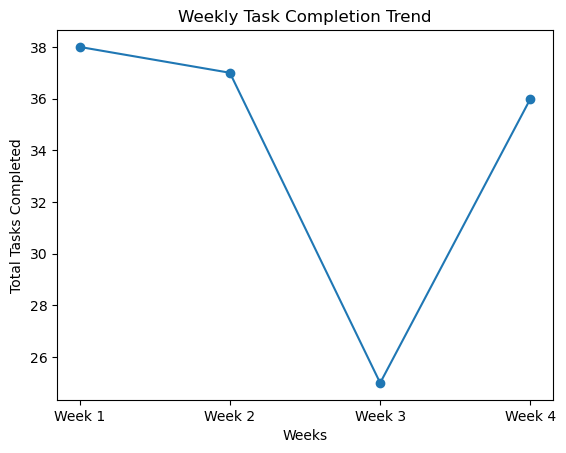

In [14]:
plt.figure()

plt.plot(weeks, values, marker='o')

plt.title("Weekly Task Completion Trend")
plt.xlabel("Weeks")
plt.ylabel("Total Tasks Completed")

plt.show()

In [15]:
weekly_totals = {
    "Week 1": df["Week 1 Tasks"].sum(),
    "Week 2": df["Week 2 Tasks"].sum(),
    "Week 3": df["Week 3 Tasks"].sum(),
    "Week 4": df["Week 4 Tasks"].sum()
}

In [16]:
weeks = list(weekly_totals.keys())
values = list(weekly_totals.values())

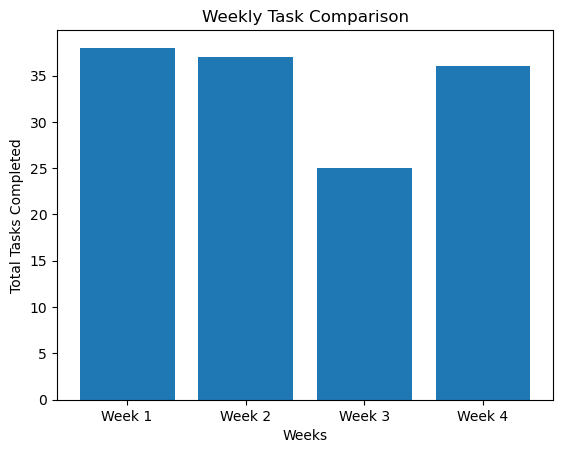

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(weeks, values)

plt.title("Weekly Task Comparison")
plt.xlabel("Weeks")
plt.ylabel("Total Tasks Completed")

plt.show()

### Insight:
- Week 4 recorded highest task completion.
- Week 2 shows slight dip.
- Overall increasing trend observed from Week 1 to Week 4.

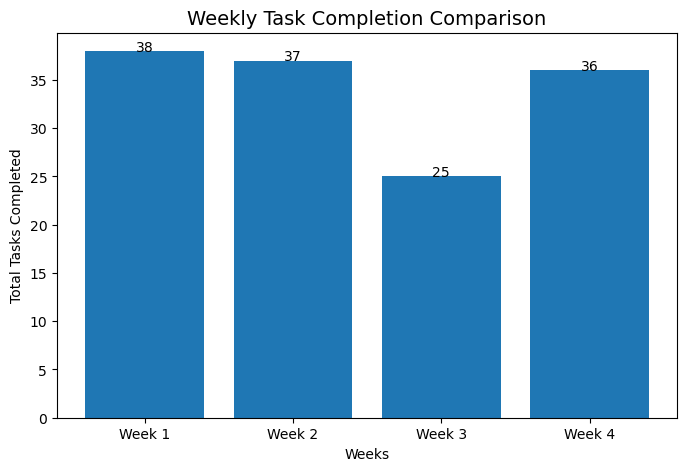

In [18]:
plt.figure(figsize=(8,5))
plt.bar(weeks, values)

plt.title("Weekly Task Completion Comparison", fontsize=14)
plt.xlabel("Weeks")
plt.ylabel("Total Tasks Completed")

for i in range(len(values)):
    plt.text(i, values[i], str(values[i]), ha='center')

plt.show()

In [19]:
top_intern = df.sort_values(by="Total Tasks Completed", ascending=False)

top_intern[["Intern Name", "Total Tasks Completed"]].head()

,Intern Name,Total Tasks Completed
13,alicia,4
15,krish,4
12,rose,4
11,vibhanshu,4
47,mehak,4


In [20]:
print("Top Performer:")
print(top_intern[["Intern Name", "Total Tasks Completed"]].iloc[0])

Top Performer:
Intern Name              alicia
Total Tasks Completed         4
Name: 13, dtype: object


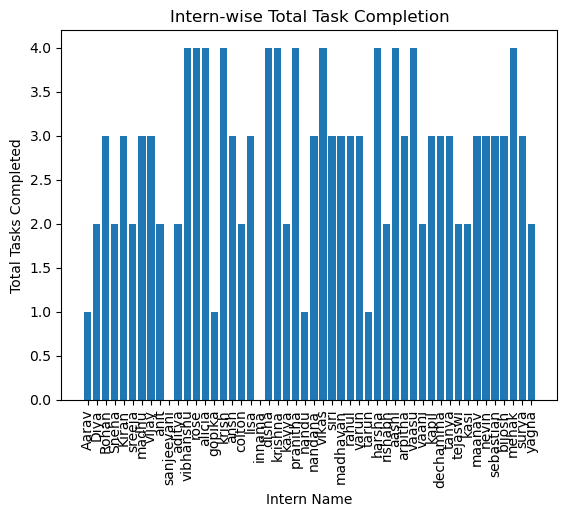

In [21]:
plt.figure()
plt.bar(df["Intern Name"], df["Total Tasks Completed"])
plt.xticks(rotation=90)
plt.title("Intern-wise Total Task Completion")
plt.xlabel("Intern Name")
plt.ylabel("Total Tasks Completed")
plt.show()

In [22]:
intern_weekly = df[["Intern Name",
                    "Week 1 Tasks",
                    "Week 2 Tasks",
                    "Week 3 Tasks",
                    "Week 4 Tasks"]]

intern_weekly.head()

,Intern Name,Week 1 Tasks,Week 2 Tasks,Week 3 Tasks,Week 4 Tasks
0,Aarav,1,0,0,0
1,Diya,0,1,0,1
2,Rohan,1,0,1,1
3,Sneha,1,1,0,0
4,Kiran,1,1,1,0


### Conclusion

Based on the weekly task analysis, Intern performance shows an overall positive trend.
Top performers demonstrate consistency and high productivity.
This module provides clear visibility into individual task completion behavior.

In [23]:
domain_weekly = df.groupby("Domain")[[
    "Week 1 Tasks",
    "Week 2 Tasks",
    "Week 3 Tasks",
    "Week 4 Tasks"
]].sum()

domain_weekly

,Week 1 Tasks,Week 2 Tasks,Week 3 Tasks,Week 4 Tasks
Domain,,,,
Data Analytics,9,7,7,8
Digital Marketing,7,6,3,5
HR & Operations,7,6,4,6
UI/UX Design,6,7,5,6
Web Development,9,11,6,11


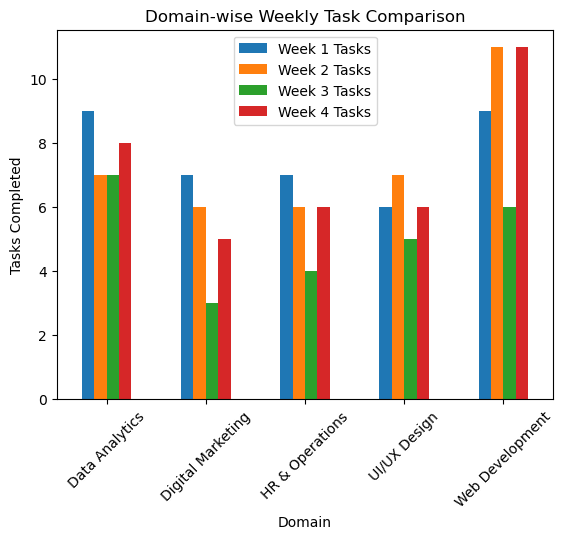

In [24]:
domain_weekly.plot(kind="bar")

plt.title("Domain-wise Weekly Task Comparison")
plt.xlabel("Domain")
plt.ylabel("Tasks Completed")
plt.xticks(rotation=45)
plt.show()

In [25]:
domain_total = domain_weekly.sum(axis=1)

domain_total.sort_values(ascending=False)

Domain
Web Development      37
Data Analytics       31
UI/UX Design         24
HR & Operations      23
Digital Marketing    21
dtype: int64

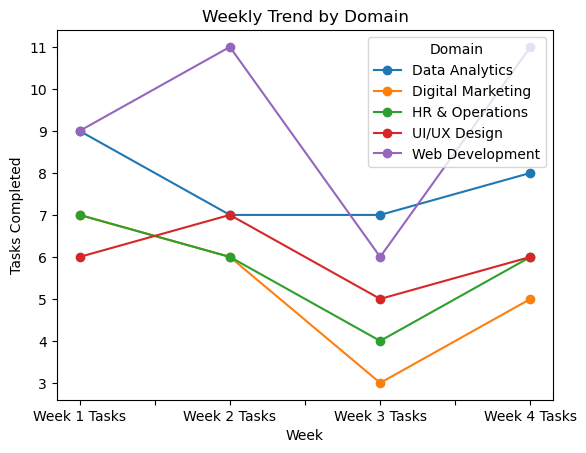

In [26]:
domain_weekly.T.plot(marker='o')

plt.title("Weekly Trend by Domain")
plt.xlabel("Week")
plt.ylabel("Tasks Completed")
plt.xticks(rotation=0)
plt.show()

In [27]:
max_week = max(weekly_totals, key=weekly_totals.get)
max_value = weekly_totals[max_week]

print("Highest Performing Week:", max_week)
print("Tasks Completed:", max_value)

Highest Performing Week: Week 1
Tasks Completed: 38


In [28]:
growth = (weekly_totals["Week 4"] - weekly_totals["Week 1"]) / weekly_totals["Week 1"] * 100
print("Overall Growth %:", round(growth,2))

Overall Growth %: -5.26


In [29]:
min_week = min(weekly_totals, key=weekly_totals.get)
min_value = weekly_totals[min_week]

print("Lowest Performing Week:", min_week)

Lowest Performing Week: Week 3


In [30]:
top_intern = df.sort_values(by="Total Tasks Completed", ascending=False)
top_intern.head(1)

,Intern ID,Intern Name,Domain,Week 1 Tasks,Week 2 Tasks,Week 3 Tasks,Week 4 Tasks,Total Tasks Completed,Total working days,Days present,Days absent,Attendence
13,114,alicia,Data Analytics,1,1,1,1,4,22,14,8,63.636364


In [31]:
domain_weekly.sum(axis=1).sort_values(ascending=False)

Domain
Web Development      37
Data Analytics       31
UI/UX Design         24
HR & Operations      23
Digital Marketing    21
dtype: int64

# Insights - Weekly Task Completion Analysis

1. Week 1 recorded the highest task completion, indicating performance improvement over time.

2. A slight dip was observed in Week 3 before performance improved again in Week 4.

3. Intern alicia emerged as the top performer based on total task completion.

4. Web Development domain contributed the highest overall task completions.

In [32]:
weekly_df.to_csv("M4_Weekly_Task_Report.csv", index=False)

In [33]:
top_intern = df.sort_values(by="Total Tasks Completed", ascending=False)

In [34]:
top_intern.to_csv("M4_Top_Performer_Report.csv", index=False)

In [35]:
top_intern.head(5).to_csv("M4_Top5_Performers.csv", index=False)

In [36]:
domain_weekly

,Week 1 Tasks,Week 2 Tasks,Week 3 Tasks,Week 4 Tasks
Domain,,,,
Data Analytics,9,7,7,8
Digital Marketing,7,6,3,5
HR & Operations,7,6,4,6
UI/UX Design,6,7,5,6
Web Development,9,11,6,11


In [37]:
domain_weekly.to_csv("M4_Domain_Weekly_Report.csv")

In [38]:
summary_data = {
    "Highest Performing Week": [max_week],
    "Highest Tasks": [max_value],
    "Lowest Performing Week": [min_week],
    "Overall Growth %": [round(growth, 2)]
}

summary_df = pd.DataFrame(summary_data)

summary_df

,Highest Performing Week,Highest Tasks,Lowest Performing Week,Overall Growth %
0,Week 1,38,Week 3,-5.26


In [39]:
summary_df.to_csv("M4_Summary_Report.csv", index=False)

In [40]:
domain_weekly.to_csv("M4_Domain_Wise_Report.csv")

In [41]:
with pd.ExcelWriter("M4_Task_Completion_Module_Report.xlsx") as writer:
    weekly_df.to_excel(writer, sheet_name="Weekly Summary", index=False)
    top_intern.to_excel(writer, sheet_name="Intern Ranking", index=False)
    domain_weekly.to_excel(writer, sheet_name="Domain Analysis")

print("Export Completed Successfully")

Export Completed Successfully


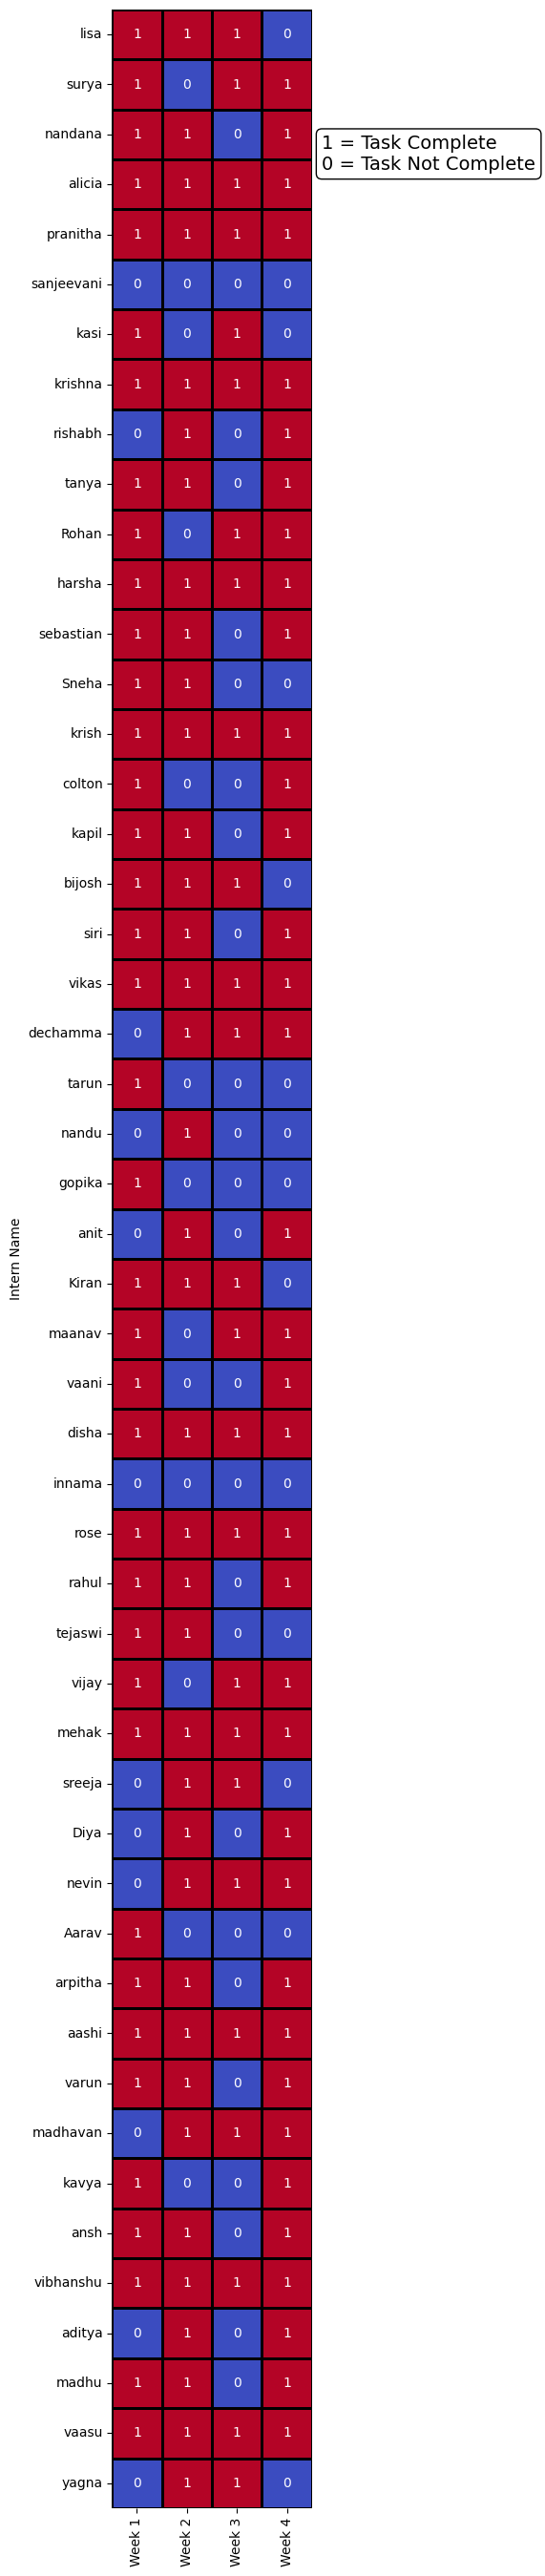

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel('Intern_Performance_Dashboard.xlsx')
weeks = ['Week 1 Tasks', 'Week 2 Tasks', 'Week 3 Tasks', 'Week 4 Tasks']

df[weeks] = df[weeks].replace({'yes': 1, 'no': 0})

plt.figure(figsize=(22, 34))
data = df.sort_values('Domain').set_index('Intern Name')[weeks]

ax = sns.heatmap(data, 
                 annot=True, cmap='coolwarm', fmt='d',
                 linewidths=2, linecolor='black',
                 square=True,
                 cbar=False)  

ax.set_xticklabels(['Week 1', 'Week 2', 'Week 3', 'Week 4'])


plt.text(1.05, 0.95, '1 = Task Complete\n0 = Task Not Complete', 
         transform=ax.transAxes, fontsize=14,
         verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black'))

plt.savefig('heatmap_vertical.png', dpi=300, bbox_inches='tight')
plt.show()


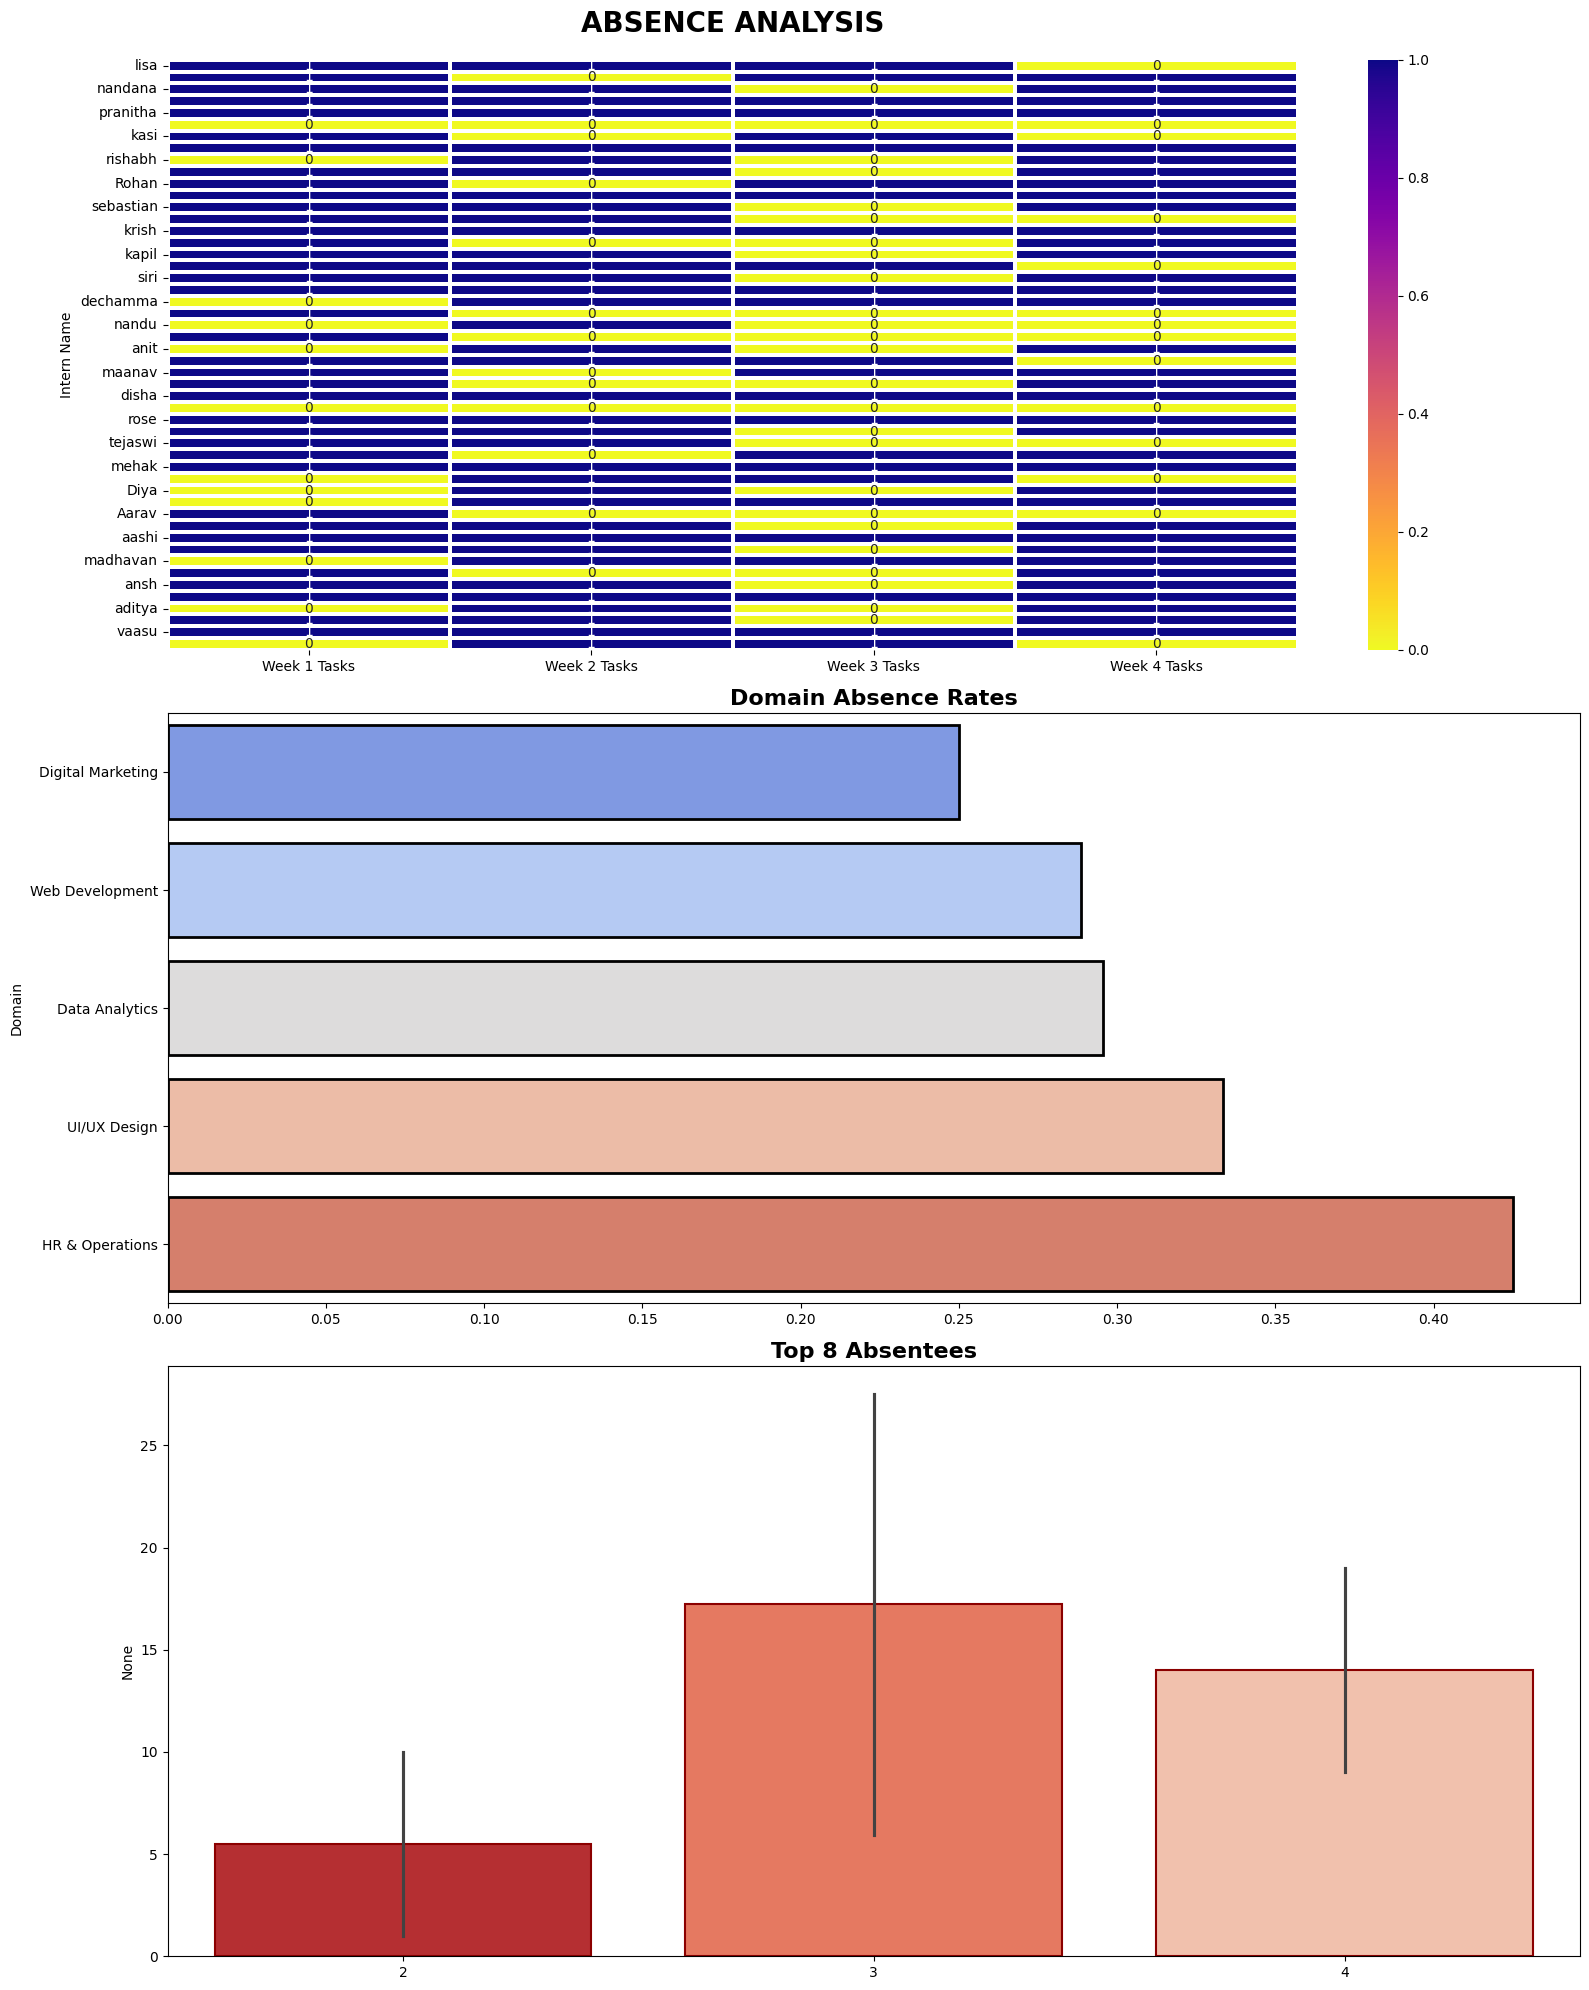

In [30]:

weeks = ['Week 1 Tasks', 'Week 2 Tasks', 'Week 3 Tasks', 'Week 4 Tasks']
df[weeks] = df[weeks].replace({'yes': 1, 'no': 0})

fig = plt.figure(figsize=(16, 20))

ax1 = plt.subplot(3, 1, 1)
sns.heatmap(df.sort_values('Domain').set_index('Intern Name')[weeks], 
            annot=True, cmap='plasma_r', linewidths=1.5, linecolor='white', ax=ax1)
ax1.set_title('ABSENCE ANALYSIS', fontsize=20, fontweight='bold', pad=20)

ax2 = plt.subplot(3, 1, 2)
domain_absence = (1-df[weeks]).groupby(df['Domain']).mean().mean(axis=1).sort_values()
sns.barplot(x=domain_absence.values, y=domain_absence.index, ax=ax2, 
            palette='coolwarm', edgecolor='black', linewidth=2)
ax2.set_title('Domain Absence Rates', fontsize=16, fontweight='bold')

ax3 = plt.subplot(3, 1, 3)
absence_top = (1-df[weeks]).sum(axis=1).sort_values(ascending=False)[:8]
sns.barplot(x=absence_top.values, y=absence_top.index, ax=ax3, 
            palette='Reds_r', edgecolor='darkred', linewidth=1.5)
ax3.set_title('Top 8 Absentees', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('absence_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()


In [32]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('Intern_Performance_Dashboard.xlsx')
weeks = ['Week 1 Tasks', 'Week 2 Tasks', 'Week 3 Tasks', 'Week 4 Tasks']
df[weeks] = df[weeks].replace({'yes': 1, 'no': 0})

with pd.ExcelWriter('Complete_Intern_Report.xlsx', engine='openpyxl') as writer:
    
    # Sheet 1: Raw Data + Summary
    summary_df = df[['Intern ID', 'Intern Name', 'Domain'] + weeks].copy()
    summary_df['Tasks Missed'] = (1 - df[weeks]).sum(axis=1)
    summary_df['Attendance %'] = df[weeks].mean(axis=1) * 100
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
    
    # Sheet 2: Heatmap Data (pivot format)
    heatmap_data = summary_df.set_index(['Intern Name', 'Domain'])[weeks].unstack('Domain')
    heatmap_data.to_excel(writer, sheet_name='Heatmap_Data')
    
    # Sheet 3: Absence Patterns
    absence_df = (1 - df[weeks]).sum(axis=1).sort_values(ascending=False)
    absence_df = pd.DataFrame({'Tasks Missed': absence_df}).join(df[['Intern Name', 'Domain']])
    absence_df.to_excel(writer, sheet_name='Absence_Patterns', index=False)

print(" Complete report exported: Complete_Intern_Report.xlsx")
print(" Sheets: Summary | Heatmap_Data | Absence_Patterns")


 Complete report exported: Complete_Intern_Report.xlsx
 Sheets: Summary | Heatmap_Data | Absence_Patterns


<h3> KPI Calculation</h3>

<p> We calculate two important Key Performance Indicators (KPIs):
<ul>
<li>Task Completion Score</li>
<li>Attendance Score</li>
Task completion is normalized to a 0–100 scale to match attendance percentage.</ul></p>

In [27]:
# Finding maximum tasks completed (for normalization)
max_tasks = df["Total Tasks Completed"].max()

# Convert task completion to score out of 100
df["Task Score"] = (df["Total Tasks Completed"] / max_tasks) * 100

# Attendance already exists as percentage
df["Attendance Score"] = df["Attendence"]

# Display updated dataset
df.head()

,Intern ID,Intern Name,Domain,Week 1 Tasks,Week 2 Tasks,Week 3 Tasks,Week 4 Tasks,Total Tasks Completed,Total working days,Days present,Days absent,Attendence,Task Score,Attendance Score
0,101,Aarav,Web Development,yes,no,no,no,1,22,20,2,90.909091,25.0,90.909091
1,102,Diya,UI/UX Design,no,yes,no,yes,2,22,19,3,86.363636,50.0,86.363636
2,103,Rohan,Data Analytics,yes,no,yes,yes,3,22,21,1,95.454545,75.0,95.454545
3,104,Sneha,Digital Marketing,yes,yes,no,no,2,22,19,3,86.363636,50.0,86.363636
4,105,Kiran,HR & Operations,yes,yes,yes,no,3,22,0,22,0.000000,75.0,0.000000


<b>
Observation</b>
<ul>
<li>Interns who completed more tasks get a higher Task Score</li>.
<li>Attendance score directly reflects intern presence.</li>
</ul>

<h3>Performance Scoring Model</h3>

In [28]:
# Calculating overall performance score

df["Performance Score"] = (
    (df["Task Score"] * 0.6) +
    (df["Attendance Score"] * 0.4)
)

# Rounding the score for better readability
df["Performance Score"] = df["Performance Score"].round(2)

# Displaying updated data
df.head()

,Intern ID,Intern Name,Domain,Week 1 Tasks,Week 2 Tasks,Week 3 Tasks,Week 4 Tasks,Total Tasks Completed,Total working days,Days present,Days absent,Attendence,Task Score,Attendance Score,Performance Score
0,101,Aarav,Web Development,yes,no,no,no,1,22,20,2,90.909091,25.0,90.909091,51.36
1,102,Diya,UI/UX Design,no,yes,no,yes,2,22,19,3,86.363636,50.0,86.363636,64.55
2,103,Rohan,Data Analytics,yes,no,yes,yes,3,22,21,1,95.454545,75.0,95.454545,83.18
3,104,Sneha,Digital Marketing,yes,yes,no,no,2,22,19,3,86.363636,50.0,86.363636,64.55
4,105,Kiran,HR & Operations,yes,yes,yes,no,3,22,0,22,0.000000,75.0,0.000000,45.00


<b>Observation</b>
<ul>
<li>Interns with both high productivity and good attendance will achieve higher scores.</li>
</ul>    

### Intern Ranking

In [29]:
# Ranking the interns based on performance score

df["Rank"] = df["Performance Score"].rank(ascending=False)

# Sorting the dataset by performance score
performance_ranking = df.sort_values(by="Performance Score", ascending=False)

# Displaying the top performers
performance_ranking.head(10)

,Intern ID,Intern Name,Domain,Week 1 Tasks,Week 2 Tasks,Week 3 Tasks,Week 4 Tasks,Total Tasks Completed,Total working days,Days present,Days absent,Attendence,Task Score,Attendance Score,Performance Score,Rank
36,137,vaasu,Web Development,yes,yes,yes,yes,4,22,22,0,100.000000,100.0,100.000000,100.00,4.0
12,113,rose,UI/UX Design,yes,yes,yes,yes,4,22,22,0,100.000000,100.0,100.000000,100.00,4.0
47,148,mehak,UI/UX Design,yes,yes,yes,yes,4,22,22,0,100.000000,100.0,100.000000,100.00,4.0
20,121,disha,UI/UX Design,yes,yes,yes,yes,4,22,22,0,100.000000,100.0,100.000000,100.00,4.0
23,124,pranitha,Data Analytics,yes,yes,yes,yes,4,22,22,0,100.000000,100.0,100.000000,100.00,4.0
21,122,krishna,Data Analytics,yes,yes,yes,yes,4,22,22,0,100.000000,100.0,100.000000,100.00,4.0
11,112,vibhanshu,Web Development,yes,yes,yes,yes,4,22,22,0,100.000000,100.0,100.000000,100.00,4.0
26,127,vikas,HR & Operations,yes,yes,yes,yes,4,22,21,1,95.454545,100.0,95.454545,98.18,8.0
32,133,harsha,Digital Marketing,yes,yes,yes,yes,4,22,19,3,86.363636,100.0,86.363636,94.55,9.0
34,135,aashi,Web Development,yes,yes,yes,yes,4,22,17,5,77.272727,100.0,77.272727,90.91,10.0


<b>Observation</b>
<ul>
<li>The ranking identifies top-performing interns.</li>
<li>These interns can be considered for recognition or rewards.</li>
</ul>

<h3> Performance Categories </h3>

In [30]:
# Creating performance categories of the interns

df["Performance Category"] = pd.cut(
    df["Performance Score"],
    bins=[0, 50, 70, 85, 100],
    labels=[
        "Low Performer",
        "Average Performer",
        "Good Performer",
        "Excellent Performer"
    ]
)

# Displaying the categorized data
df[["Intern Name","Performance Score","Performance Category"]].head()

,Intern Name,Performance Score,Performance Category
0,Aarav,51.36,Average Performer
1,Diya,64.55,Average Performer
2,Rohan,83.18,Good Performer
3,Sneha,64.55,Average Performer
4,Kiran,45.00,Low Performer


<b>Observation</b>
Interns are grouped into four categories:
<table>
    <tr>
        <th>Score Range</th>
        <th>Category</th>
    </tr>
    <tr>
        <td>0-50</td>
        <td>Low Performer</td>
    </tr>
    <tr>
        <td>50-70</td>
        <td>Average Performer</td>
    </tr>
    <tr>
        <td>70-85</td>
        <td>Good Performer</td>
    </tr>
    <tr>
        <td>85-100</td>
        <td>Excellent Performer</td>
    </tr>
</table>


### Intern ranking chart

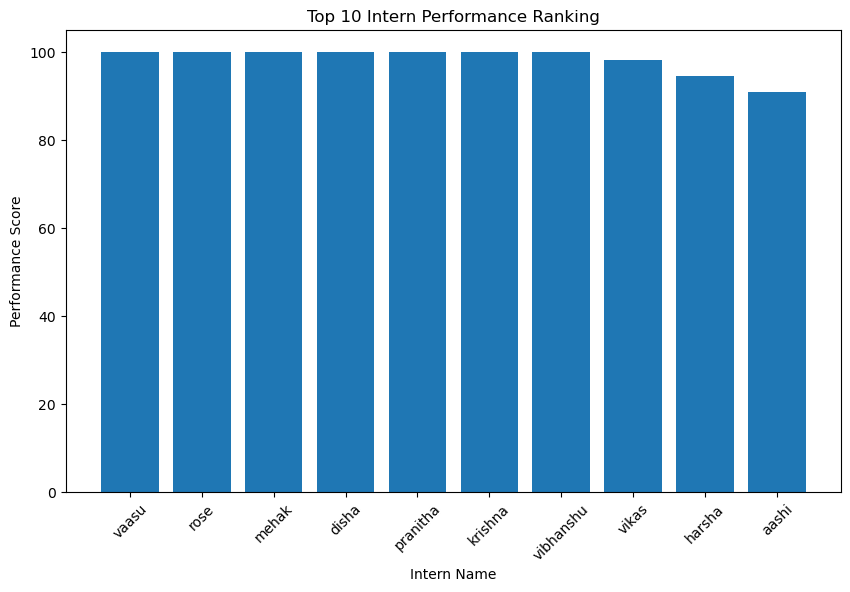

In [31]:
# Selecting the top 10 interns

top10 = performance_ranking.head(10)

plt.figure(figsize=(10,6))

plt.bar(top10["Intern Name"], top10["Performance Score"])

plt.title("Top 10 Intern Performance Ranking")

plt.xlabel("Intern Name")
plt.ylabel("Performance Score")

plt.xticks(rotation=45)

plt.show()

### Domain-wise Performance Analysis

In [32]:
# Calculating the average performance score for each domain

domain_performance = df.groupby("Domain")["Performance Score"].mean().sort_values(ascending=False)
domain_performance

Domain
Web Development      78.496154
Data Analytics       74.833636
Digital Marketing    74.611429
UI/UX Design         73.738889
HR & Operations      61.591000
Name: Performance Score, dtype: float64

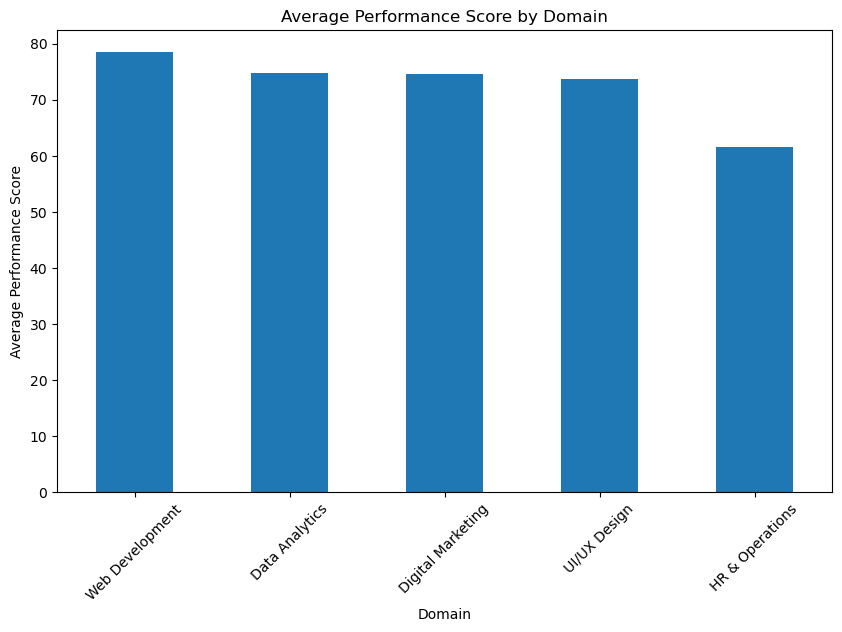

In [33]:
plt.figure(figsize=(10,6))

domain_performance.plot(kind="bar")

plt.title("Average Performance Score by Domain")

plt.xlabel("Domain")
plt.ylabel("Average Performance Score")

plt.xticks(rotation=45)

plt.show()

### Export Performance Report

In [34]:
# Export CSV reports

performance_ranking.to_csv("Performance_Ranking_Report.csv", index=False)

domain_performance.to_csv("Domain_Performance_Report.csv")

df.to_csv("Performance_Full_Report.csv", index=False)


# Export Excel report

with pd.ExcelWriter("Performance_Module_Report.xlsx") as writer:

    performance_ranking.to_excel(writer,
                                 sheet_name="Intern Ranking",
                                 index=False)

    domain_performance.to_excel(writer,
                                sheet_name="Domain Performance")

    df.to_excel(writer,
                sheet_name="Full Dataset",
                index=False)

print("Performance reports exported successfully.")

Performance reports exported successfully.



# M7 – Domain Comparison Analysis

This module compares intern performance across different **Domains**.

**Objectives**
- Compare average performance score by domain
- Compare total tasks completed by domain
- Compare average attendance by domain
- Generate a combined comparison report


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Domain level aggregation
domain_summary = df.groupby("Domain").agg({
    "Tasks Completed":"sum",
    "Attendance (%)":"mean",
    "Performance Score":"mean"
}).reset_index()

domain_summary = domain_summary.sort_values("Performance Score", ascending=False)

domain_summary


In [ ]:

# Average Performance Score by Domain
plt.figure()
domain_summary.plot(x="Domain", y="Performance Score", kind="bar")
plt.title("Average Performance Score by Domain")
plt.ylabel("Performance Score")
plt.show()


In [ ]:

# Total Tasks Completed by Domain
plt.figure()
domain_summary.plot(x="Domain", y="Tasks Completed", kind="bar")
plt.title("Total Tasks Completed by Domain")
plt.ylabel("Tasks Completed")
plt.show()


In [ ]:

# Average Attendance by Domain
plt.figure()
domain_summary.plot(x="Domain", y="Attendance (%)", kind="bar")
plt.title("Average Attendance by Domain")
plt.ylabel("Attendance (%)")
plt.show()


In [ ]:

# Export Domain Comparison Report
domain_summary.to_csv("M7_Domain_Comparison_Report.csv", index=False)
domain_summary.to_excel("M7_Domain_Comparison_Report.xlsx", index=False)

print("M7 Report Exported Successfully")
